In [18]:
import numpy as np
import pyrepseq as prs
import matplotlib.pyplot as plt

import repertoire_simulator.lib as lib


plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../data/"

In [19]:
c = np.load(DATA_PATH + "sim_results/simple_sim.npz")["clonal_abundances"]

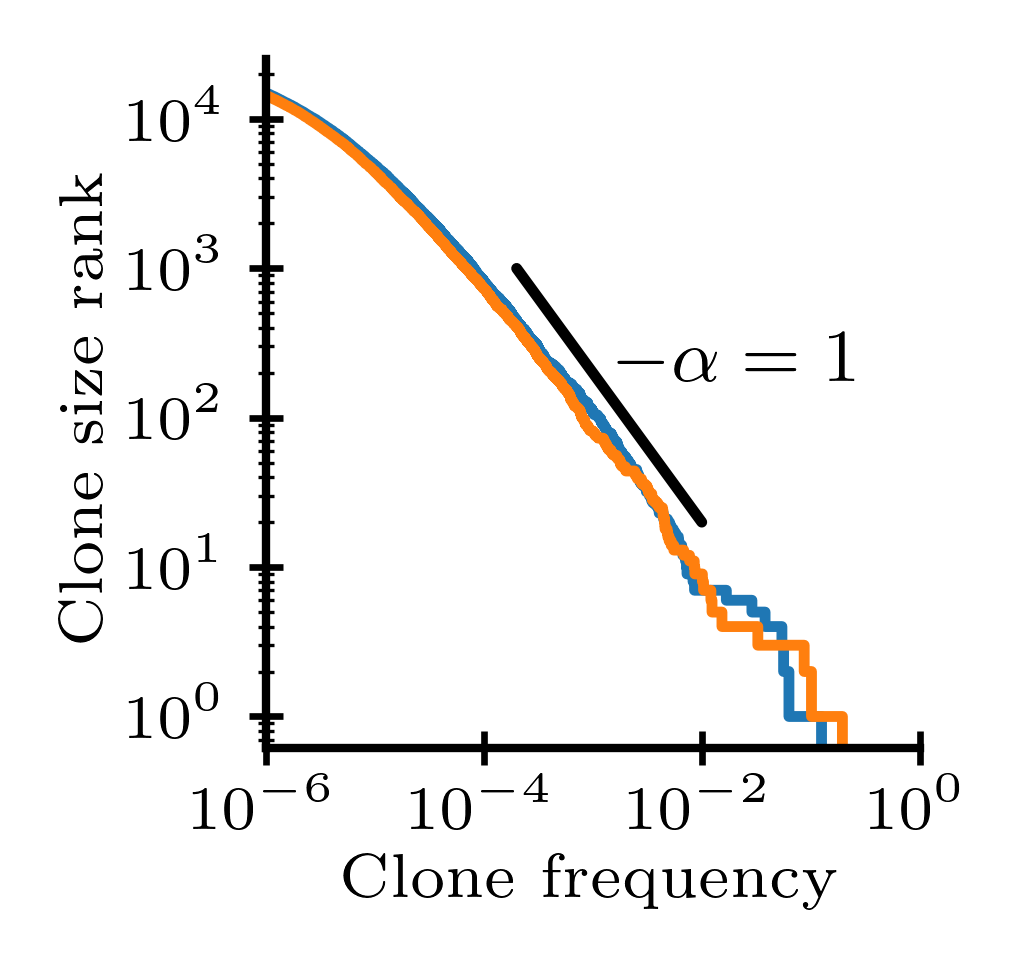

In [46]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[2e-4, 1e-2], factor=2e-1, exponent=-1)
for i in range(c.shape[1]):
    prs.plotting.rankfrequency(c[:, i][c[:, i] >= 1], ax=ax, normalize_x=True, label=f'i = {i+1}')
    
ax.set_xlim([1e-6, 1e0]);

## Trajectories

In [26]:
records = np.load(DATA_PATH + "sim_results/simple_sim_record.npz", allow_pickle=True)
t = records['t']
c_t = records['c']

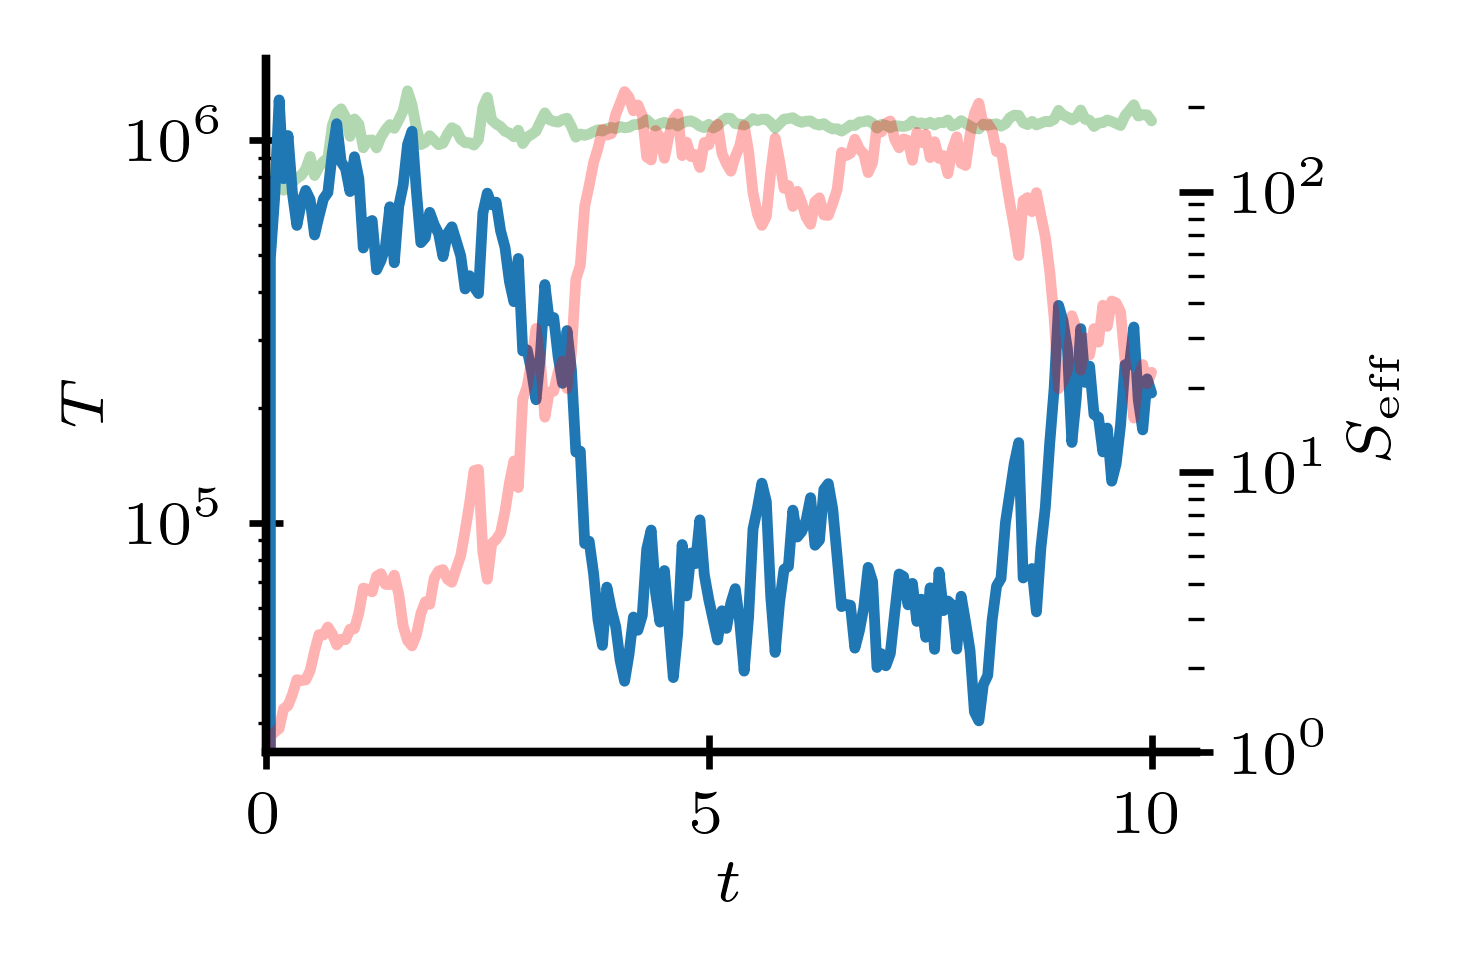

In [27]:
fig, ax1 = plt.subplots(figsize=(2, 1.5))

T = np.zeros(len(t))
Seff = np.zeros(len(t))
cmaxes = np.zeros(len(t))
for i, time in enumerate(t):
    T[i] = np.mean(c_t[i].sum(axis=0))
    Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
    cmaxes[i] = np.nanmax(c_t[i])
    
ax1.plot(t, T, c='green', alpha=0.3)
ax1.set_xlim(0, None)
# ax1.set_ylim(0, None)
ax1.set_yscale('log')
ax1.set_xlabel(r"$t$")
ax1.set_ylabel(r"$T$")
# 
ax1.plot(t, cmaxes);

ax2 = ax1.twinx()

ax2.plot(t, Seff, c='red', alpha=0.3)
ax2.set_yscale('log')
ax2.set_ylim(1, None)
ax2.set_ylabel(r"$S_{\mathrm{eff}}$");
ax2.tick_params(axis='y');

# Two point inequality 

In [28]:
import numpy as np
from functools import partial
from scipy.special import kv
from scipy.special import pbdv
from scipy.special import gamma
from scipy import integrate
from scipy.optimize import root_scalar

def density_x_white_noise(x, M, D):
        
    Z = 2 * kv(0, M / (2 * D))
    
    return 1 / Z * np.exp(- M / (2 * D) * np.cosh(x))

def unnormalized_density_x_coloured_noise(x, M, D, lamb):
    
    return (1 + M/lamb * np.cosh(x)) * np.exp(- M /(2 * D) * (1 + M / (2 * lamb) * np.cosh(x)) * np.cosh(x))

def partition_function_x_coloured_noise(M, D, lamb, x_range=200):
    
    Z = integrate.quad(unnormalized_density_x_coloured_noise, -x_range, x_range, args=(M, D, lamb))[0]
    
    return Z

def density_x_coloured_noise(x, M, D, lamb):
    
    Z = partition_function_x_coloured_noise(M, D, lamb)
    
    return 1 /Z * unnormalized_density_x_coloured_noise(x, M, D, lamb) 


def mean_field_steady_state_density_x_white_noise(x, M, D):
    
    Z = (gamma(M / D + 1) **2) / gamma(2 * (M /D + 1))
        
    return 1 / Z * (1 + np.exp(-x)) ** (- 2 * (M /D + 1)) * np.exp(- (M / D + 1) * x)

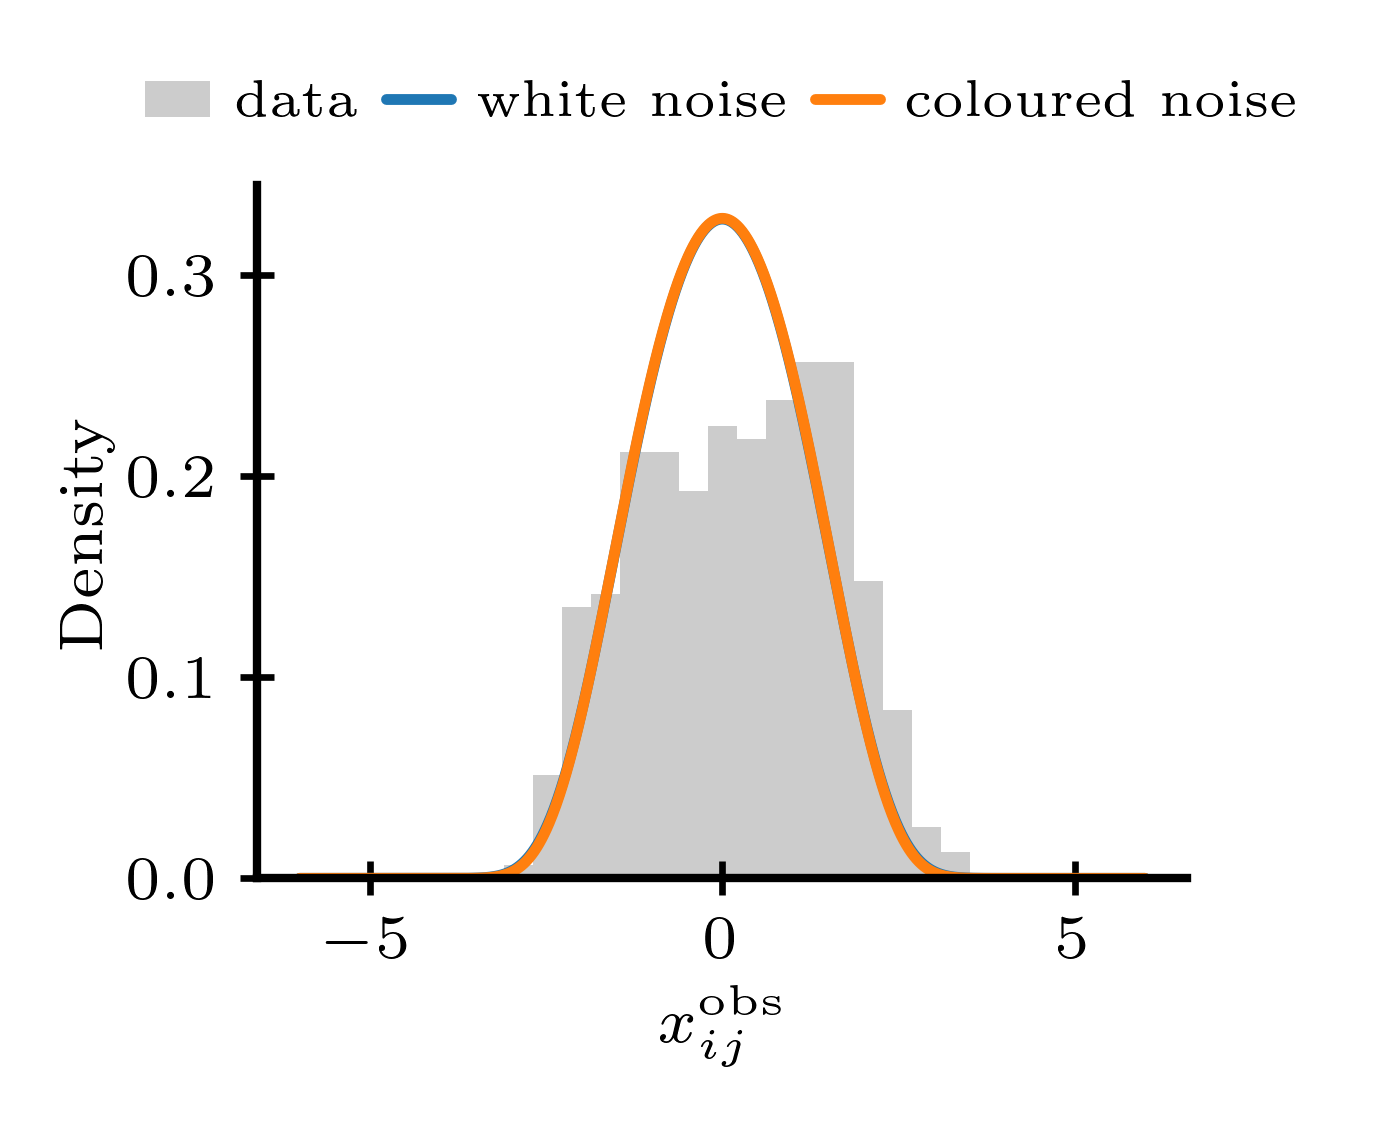

In [47]:
fig, ax = plt.subplots(figsize=(2, 1.5))
x_bound = 6
bins = np.linspace(-x_bound, x_bound, 30)
ax.hist(lib.get_empirical_log_ratios(c[:, 0], c[:, 1], threshold=500, base=np.exp(1)), density=True, bins=bins, alpha=0.2, color='black', label='data')

xs = np.linspace(-x_bound, x_bound, 1000)

M = 1
D = 1
lamb = 100

ax.plot(xs, density_x_white_noise(xs, M=M, D=D), label='white noise')
ax.plot(xs, density_x_coloured_noise(xs, M=M, D=D, lamb=lamb), label='coloured noise')
#ax.plot(xs, mean_field_steady_state_density_x_white_noise(xs, M=M, D=D), label='mean field')
# ax.plot(xs, mean_field_steady_state_density_x_coloured_noise(xs, M=M, D=D, lamb=lamb, approximate_zeta=True))

ax.set_xlabel(r'$x^{\mathrm{obs}}_{ij}$')
ax.set_ylabel('Density')
ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=4, frameon=False);

In [12]:

def self_consistency_eqn(zeta, M, D, lamb):
    
    alpha = (M**2) / (2.0 * D * lamb)
    beta  = (M - (M / lamb) * (zeta + M)) / D
    nu = (zeta + M) / D
    
    z = beta / np.sqrt(2.0 * alpha)    
    Dv, Dv_prime = pbdv(-nu, z) 
    r1 = (z / 2.0) - (Dv_prime / Dv) 
    r2 = (z - r1) / (-nu)
    
    return np.sqrt(2.0 * alpha) / (nu - 1.0) * r1 + (M / lamb - 1.0) - M / lamb * (1.0 / np.sqrt(2.0 * alpha)) * nu * r2

def solve_zeta(M, D, lamb, eps=1e-12):

    sol = root_scalar(partial(self_consistency_eqn, M=M, D=D, lamb=lamb), method="brentq", bracket=(D * (1.0 + eps) - M, D), maxiter=10000)

    if (not sol.converged) or (not np.isfinite(sol.root)):
        raise RuntimeError(f"Root solve failed at D={D}, M={M}, lambda={lamb}")

    return sol.root

def weak_noise_approximation_for_zeta(M, D, lamb):
    
    M = np.asarray(M)
    D = np.asarray(D)
    lamb = np.asarray(lamb)

    return D * (lamb / (lamb + M))

def parabolic_cylinder(nu, beta):
    return pbdv(nu, beta)[0]

def modified_parabolic_cylinder(nu, alpha, beta):
    
    return (2 * alpha) ** (- nu / 2) * gamma(nu) * np.exp((beta ** 2) / (8 * alpha)) * parabolic_cylinder(-nu, beta / np.sqrt(2 * alpha))

def partition_function_y_coloured_noise(M, D, lamb, zeta):
    
    nu = (zeta + M) / D
    beta = (M - M / lamb * (zeta + M)) / D
    alpha = (M / lamb * M) / (2 * D)
    
    return modified_parabolic_cylinder(nu, alpha, beta) + M / lamb * modified_parabolic_cylinder(nu + 1, alpha, beta)

def mean_field_steady_state_density_y_coloured_noise(y, M, D, lamb, approximate_zeta=False):
    
    if not approximate_zeta:
        zeta = solve_zeta(M, D, lamb)
        
    else:
        zeta =  weak_noise_approximation_for_zeta(M, D, lamb)
    
    Z = partition_function_y_coloured_noise(M, D, lamb, zeta)
    
    return 1 / Z * (1 + M / lamb * np.exp(-y)) * np.exp(- 1 /D * ( (M**2 / lamb) / 2 * np.exp(-2 * y) + (M - M / lamb * (zeta + M)) * np.exp(-y) + (zeta + M) * y))

def mean_field_steady_state_density_x_coloured_noise(x, M, D, lamb, approximate_zeta=False):
    
    if not approximate_zeta:
        zeta = solve_zeta(M, D, lamb)
        
    else:
        zeta =  weak_noise_approximation_for_zeta(M, D, lamb)
    
    Z = partition_function_y_coloured_noise(M, D, lamb, zeta)
    
    nu = (zeta + M) / D
    beta = (M - M / lamb * (zeta + M)) / D
    alpha = (M / lamb * M) / (2 * D)
    
    A_x = alpha * (1 + np.exp(- 2 * x))
    B_x = beta * (1 + np.exp(-x))
    
    I1 = modified_parabolic_cylinder(2 * nu, A_x, B_x)
    I2 = modified_parabolic_cylinder(2 * nu + 1 , A_x, B_x)
    I3 = modified_parabolic_cylinder(2 * nu + 2, A_x, B_x)
    
    return (np.exp( - nu * x) / (Z ** 2)) * (I1 + M / lamb * (1 + np.exp(-x)) * I2 + ((M / lamb)**2 * np.exp(-x)) * I3)